# Free Space Path Loss (FSPL)

Model the signal loss as the distance increases by modelling it using FSPL equations.

$$
FSPL = 20log(d) + 20log(f) - 147.55 - G_t - G_r
$$

Where:
- FSPL is in dB
- $d$ is the distance from the transmitter
- $f$ is the frequency of the wave, so 24MHz
- $G_t$ is the transmitter's gain
- $G_r$ is the receiver's gain. It's assumed this is 1 as the antenna is isotropic?

References:
- https://en.wikipedia.org/wiki/Free-space_path_loss
- https://www.pasternack.com/t-calculator-fspl.aspx
- https://www.bdamax.com/blog/db-vs-dbm-whats-the-real-difference/

In [1]:
import math

def signal_loss(distance :float, frequency = 2_400_000_000, transmitter_gain = 14, receiver_gain = 1):
    return 20 * math.log10(distance) + 20 * math.log10(frequency) - 147.55  - transmitter_gain - receiver_gain

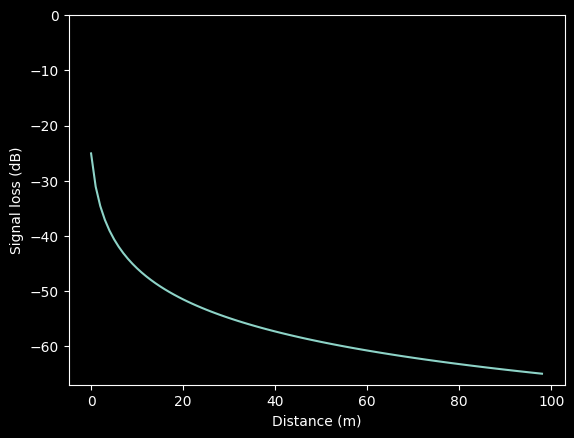

In [2]:
import matplotlib.pyplot as plt

points = []

for x in range (1, 100, 1):
    points.append(signal_loss(x) * - 1)

plt.plot(points)
plt.ylim(ymax=0)
plt.xlabel("Distance (m)")
plt.ylabel("Signal loss (dB)")
plt.show()

## Estimated vs Received Signal Strength

Model what the FSPL equation estimates the RSS should be at a given distance from the transmitter, and compare this to the actual signal strength received by the tag.

Looks at `/March 26 2025 Field Trial/straightpath5/` experiment, where the device moved ~181m.

Known inaccuracies:
- Real `transmitter_power` is unknown, but -6dBm fits the data
- The tag may not have travelled at a constant velocity in a straight line
- The entire dataset is used and it's assumed there are no pauses at the start/end and the tag doesn't retrace its steps

### Conclusion

The attenuation of the BLE signal mildly resemble the model of signal loss using FSPL equations.

### Transmitter E

First, look at transmitter A which is right by the start of the straight path

Standardising angles and times (shifting by 0.00 degrees)


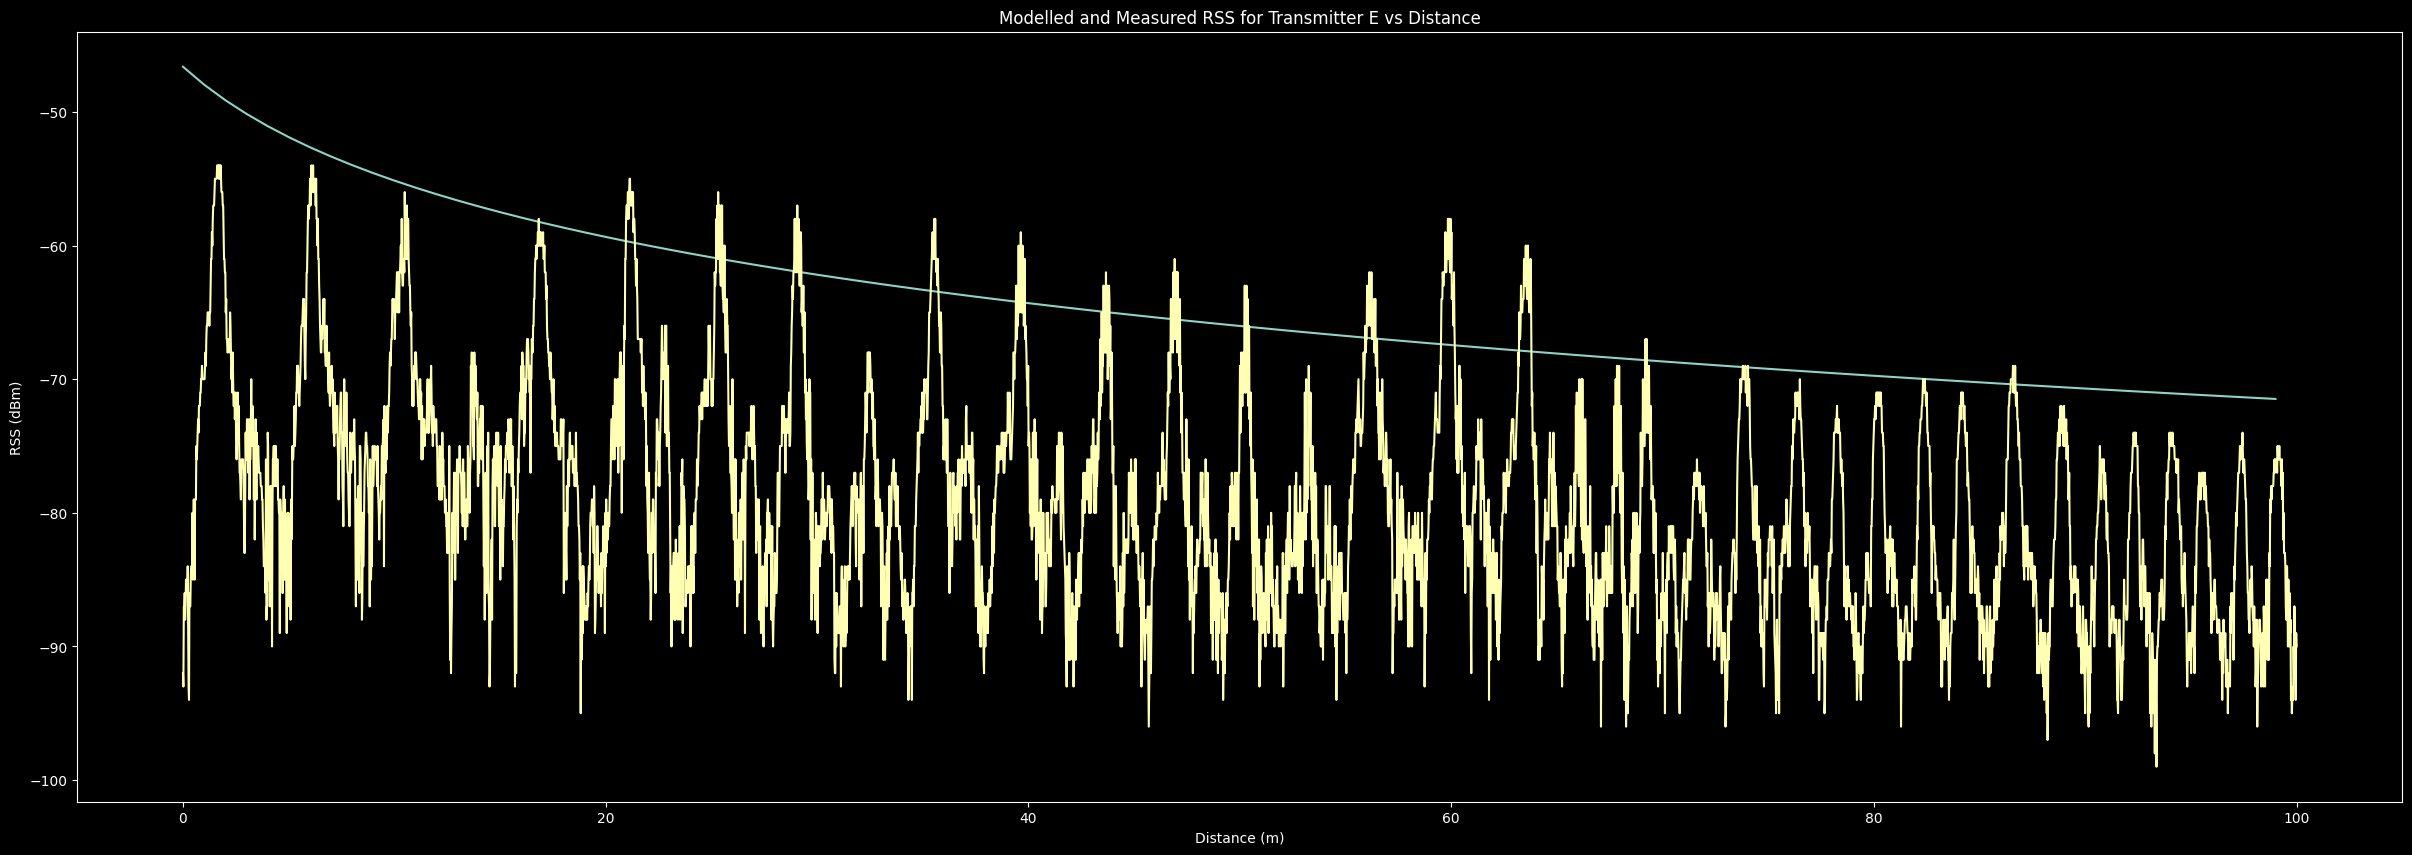

In [3]:
from BLEanalysis.signals import Signals
import numpy as np

transmitter_power = -6 # dBm
dist_travelled = 100 # m
num_data_points = 5000

# generate the model received signal strength
model_points = []

for x in range (6, dist_travelled + 6, 1):
    model_points.append(-1 * signal_loss(x) + transmitter_power)

# plot actual RSS from the tag
straight5_data = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0).data[110:num_data_points,0]
tag_x = np.linspace(0, dist_travelled, num_data_points - 110)

# draw the graphs
plt.figure(figsize=(30,10))
plt.plot(model_points)
plt.plot(tag_x, straight5_data)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter E vs Distance")
plt.show()

### Transmitter B

Examine the predicted and real RSS as the tag approaches transmitter B. It has been estimated the tag started 137m away and finished 37m away from the transmitter. Again, these measurements have been chosen on what fits the data.

Standardising angles and times (shifting by 0.00 degrees)


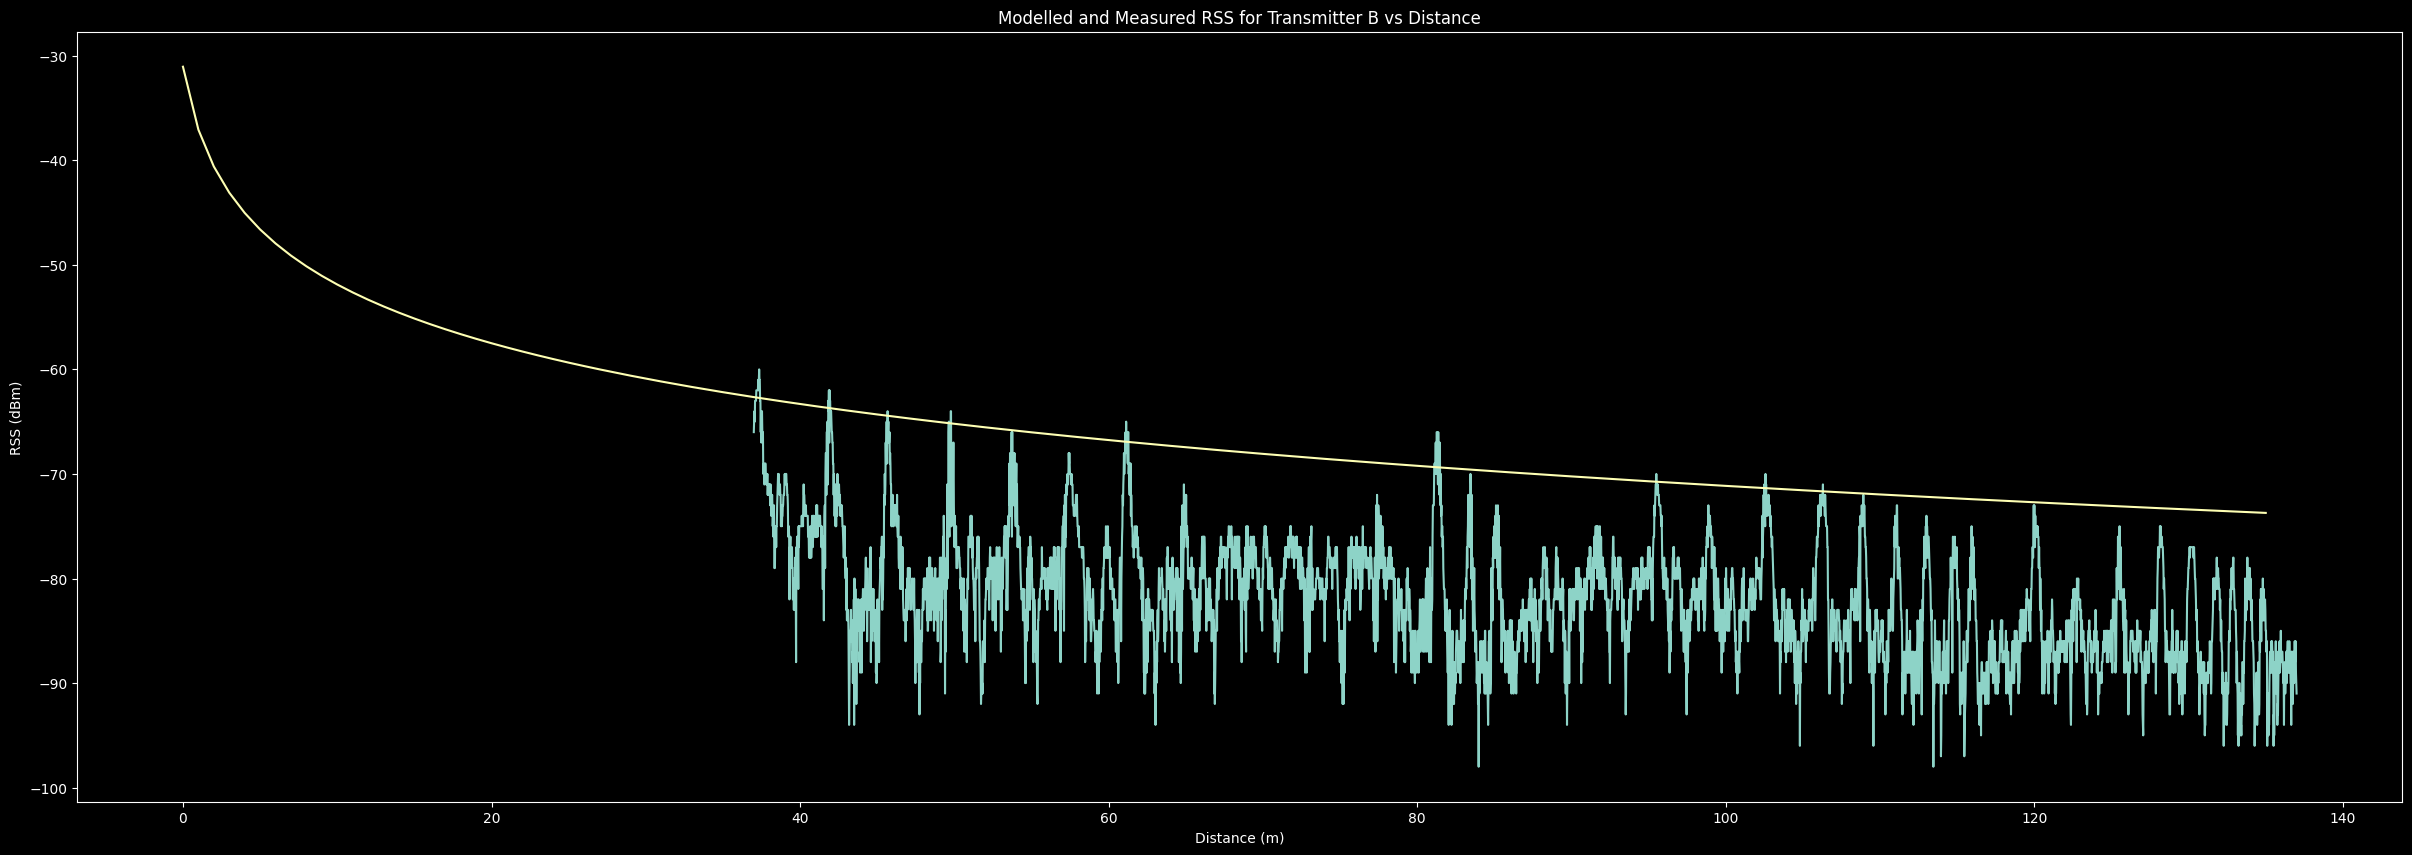

In [4]:
dist_remaining_to_b = 37 # m

straight5_data_b = np.flip(Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['b'],filetype='log',angleOffset=0).data[110:num_data_points,0])
tag_x = np.linspace(dist_remaining_to_b, dist_travelled + dist_remaining_to_b, num_data_points - 110)

b_model_points = []

for x in range (1, dist_travelled + dist_remaining_to_b, 1):
    b_model_points.append(-1 * signal_loss(x) + transmitter_power)

plt.figure(figsize=(30,10))
plt.plot(tag_x, straight5_data_b)
plt.plot(b_model_points)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter B vs Distance")
plt.show()

## Use GPS to Determine Tag Location

By cross-referencing the normalised time stamps of the GPS receiver and tag, plot the RSS of the packets when the tag is a given distance away from the transmitter. The tag starts at transmitter E and finishes at transmitter B. This is more accurate as the exact position of the tag can be found, rather than guessing its position from the path inference.

### Overview of GPS and Log Data

Analyse aspects of the GPS file to understand it better, and plot some general information about the logs from the tags.

In [5]:
from BLEanalysis.finley import *

# hard code transmitter coordinates in northing and easting. Altitudes from https://glandnav.com/tools/gps-elevation-finder
tx_a = Transmitter('a', -1.448596, 53.368606, 131.0)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0)
tx_e = Transmitter('e', -1.449990, 53.369204, 118) #113.0)

In [6]:
from copy import copy, deepcopy

# extract tag log data and gps data and convert them into objects
gps_data = GpsLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/2025-03-26_11_50_22_my_iOS_device.csv")

log_data_a = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_a, deepcopy(gps_data))
log_data_b = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_b, deepcopy(gps_data))
log_data_c = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_c, deepcopy(gps_data))
log_data_e = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_e, deepcopy(gps_data))

GpsLog | no. points: 164, time: 162.999
BleLog | tx: a, no.packets: 3756, time: 162.999s
BleLog | tx: b, no.packets: 5690, time: 162.999s
BleLog | tx: c, no.packets: 7917, time: 162.999s
BleLog | tx: e, no.packets: 5306, time: 162.999s


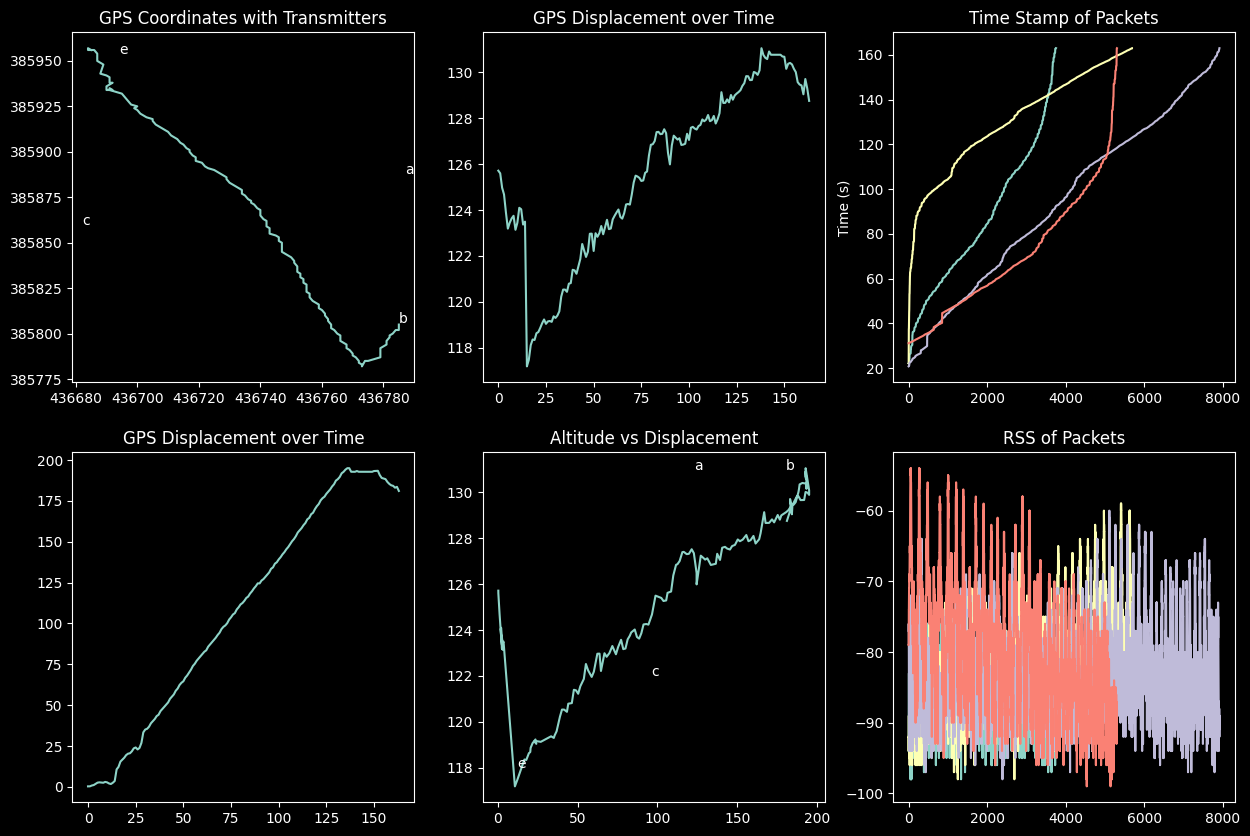

In [8]:
# plot gps coordinates and rss over time on a graph
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("GPS Coordinates with Transmitters")
plt.plot([getattr(obj, "easting") for obj in gps_data.data_points], [getattr(obj, "northing") for obj in gps_data.data_points])
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, (tx.easting, tx.northing))

plt.subplot(2, 3, 2)
plt.title("GPS Displacement over Time")
plt.plot([getattr(obj, "relative_time") for obj in gps_data.data_points], [getattr(obj, "altitude") for obj in gps_data.data_points])

plt.subplot(2, 3, 3)
plt.title("Time Stamp of Packets")
for log in [log_data_a, log_data_b, log_data_c, log_data_e]:
    plt.plot([getattr(obj, "time") for obj in log.packets])
plt.ylabel("Time (s)")

plt.subplot(2, 3, 4)
plt.title("GPS Displacement over Time")
plt.plot([getattr(obj, "relative_time") for obj in gps_data.data_points], [getattr(obj, "displacement") for obj in gps_data.data_points])

plt.subplot(2, 3, 5)
plt.title("Altitude vs Displacement")
plt.plot([getattr(obj, "displacement") for obj in gps_data.data_points], [getattr(obj, "altitude") for obj in gps_data.data_points])
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, (gps_data.dist_from_first_point(tx.easting, tx.northing, tx.altitude), tx.altitude))

plt.subplot(2, 3, 6)
plt.title("RSS of Packets")
for log in [log_data_a, log_data_b, log_data_c, log_data_e]:
    plt.plot([getattr(obj, "rss") for obj in log.packets])
plt.show()

### Transmitter E

RSS of received packets vs the modelled RSS. As shown by the graph, the model fits the data extremely well.

In [14]:
def plot_rss_vs_dist_vs_fspl(ble_log :BleLog):
    # plot RSS vs distance
    x_values = []
    y_values = []

    for packet in ble_log.packets:
        y_values.append(packet.rss)

        closest_gps_point = min(ble_log.gps_log.data_points, key=lambda point: abs(point.relative_time - packet.time))
        x_values.append(closest_gps_point.displacement)

    # plot modelled FSPL
    fspl_points = []

    for i in range (1, int(max(x_values))):
        fspl_points.append(-1 * signal_loss(i))

    plt.plot(x_values, y_values)
    plt.plot(fspl_points)
    plt.title(f"RSS vs Distance, FSPL for Transmitter {ble_log.transmitter.tx_id}")
    plt.xlabel("Distance (m)")
    plt.ylabel("RSS (dBm)")

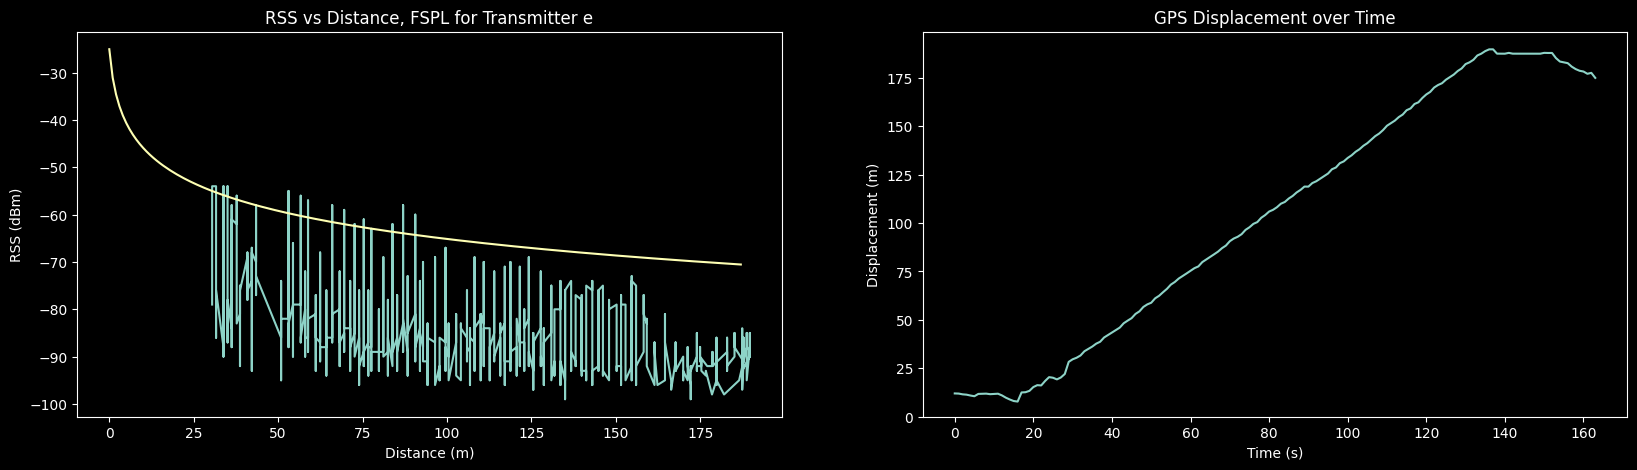

In [21]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_data_e)

plt.subplot(1, 2, 2)
plt.plot(log_data_e.gps_log.get_displacements())
plt.ylim(bottom=0)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("GPS Displacement over Time")
plt.show()

(0.0, 169.59547295913697)

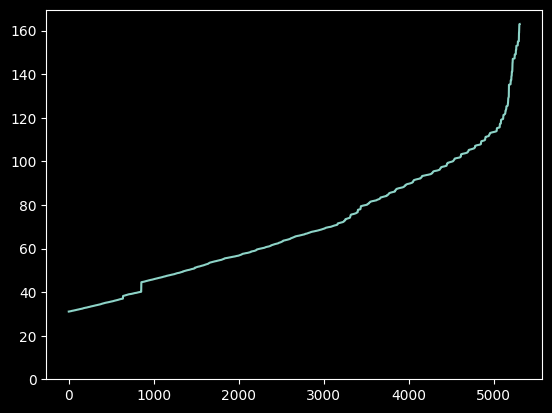

In [23]:
plt.plot([getattr(obj, "time") for obj in log_data_e.packets])
plt.ylim(bottom=0)

### Transmitter B

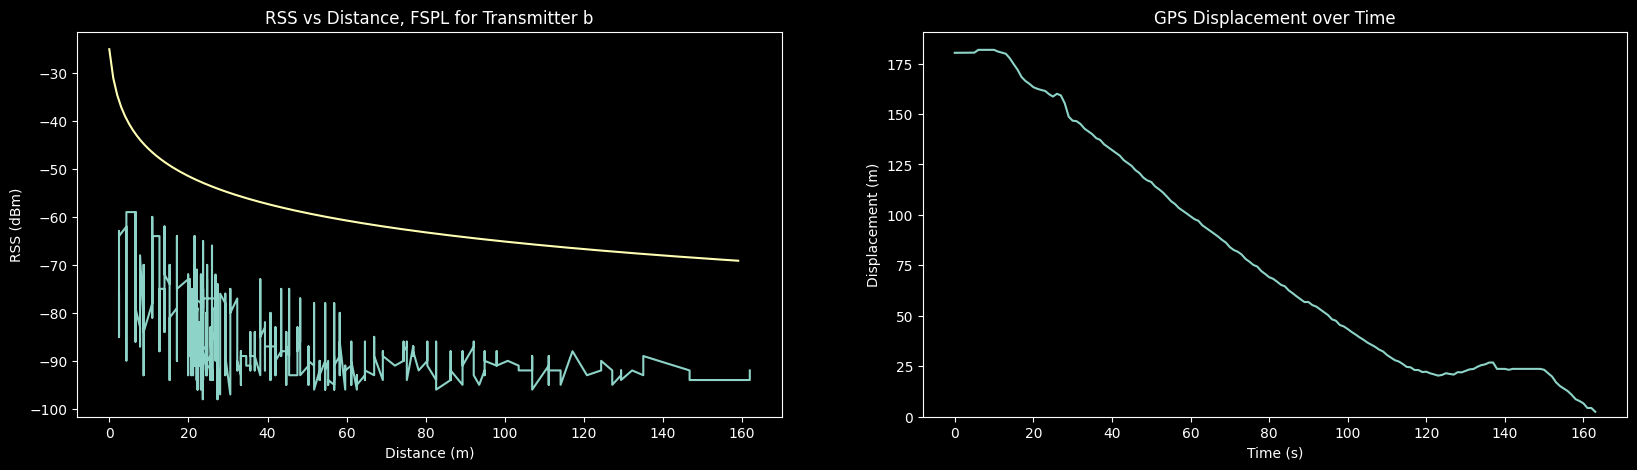

In [16]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_data_b)

plt.subplot(1, 2, 2)
plt.plot(log_data_b.gps_log.get_displacements())
plt.ylim(bottom=0)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("GPS Displacement over Time")
plt.show()

### Transmitter C

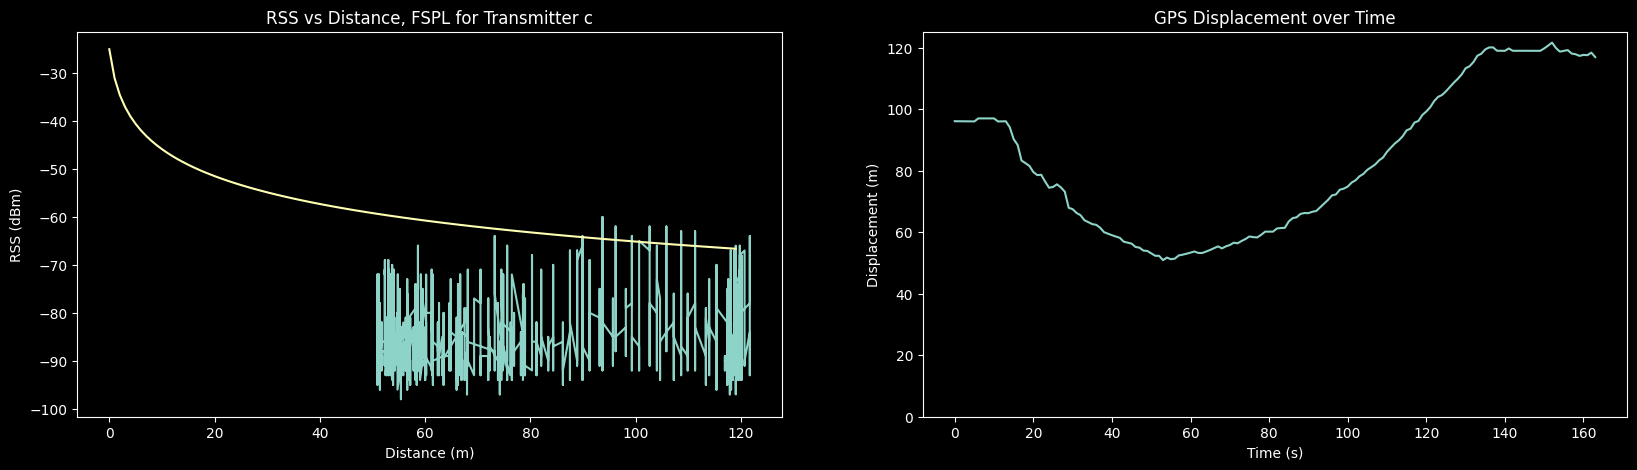

In [17]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_data_c)

plt.subplot(1, 2, 2)
plt.plot(log_data_c.gps_log.get_displacements())
plt.ylim(bottom=0)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("GPS Displacement over Time")
plt.show()

### Transmitter A

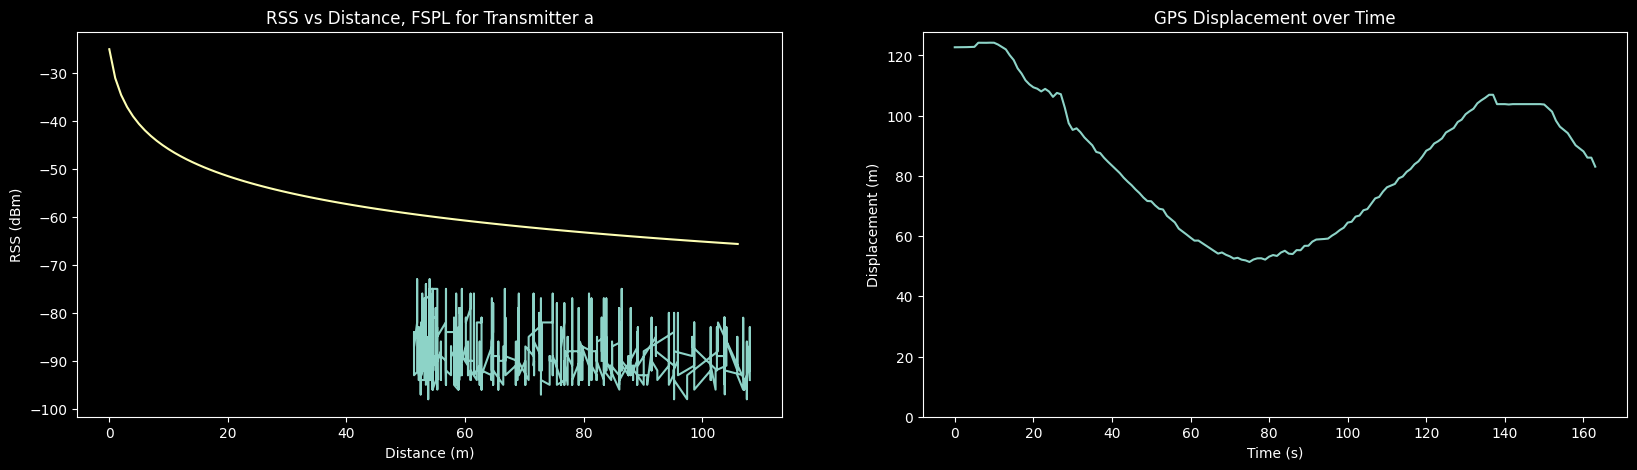

In [18]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_data_a)

plt.subplot(1, 2, 2)
plt.plot(log_data_a.gps_log.get_displacements())
plt.ylim(bottom=0)
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("GPS Displacement over Time")
plt.show()